In [54]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import read_log

In [83]:
path = '../backtests/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

In [84]:
data.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [85]:
activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

In [86]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [87]:
price_pepper['profit_and_loss'].iloc[999] + price_osmium['profit_and_loss'].iloc[999]

np.float64(9467.0)

In [88]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

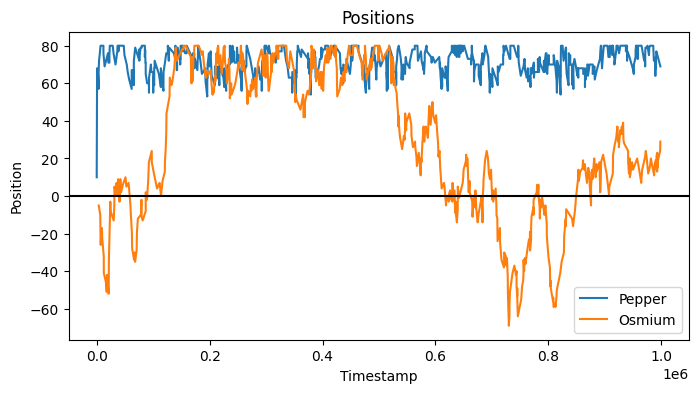

In [89]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()

In [90]:
pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

C:\Users\aeali\AppData\Local\Temp\ipykernel_3736\1080791694.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_3736\1080791694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


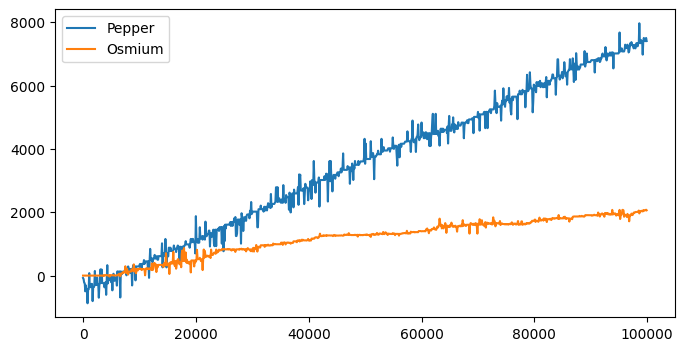

In [91]:
plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()